In [1]:
import numpy as np
import matplotlib.pyplot as pl
import matplotlib as mpl

pi = np.pi

## Constant f

In [2]:
f0 = 0.5*2*pi
t_space = np.linspace(0, 10, 2**10)
signal = np.sin(f0*t_space)
mark_idx = np.arange(0, len(signal), 30)

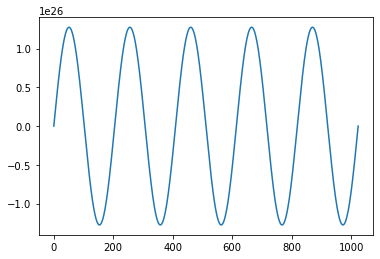

In [3]:
pl.plot([int(0.5*(i*1e24+1)*255) for i in signal])

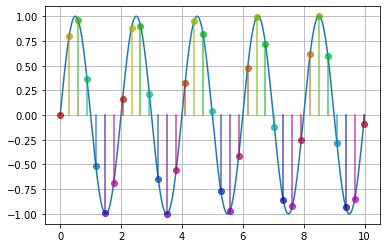

In [4]:
colorbar = mpl.colormaps['hsv']
color_arr = np.multiply(0.7,[colorbar(int(np.mod(i/2, 1)*255)) for i in t_space])
pl.plot(t_space, signal)
# pl.plot(t_space, signal, ls='', markevery=mark_idx, marker = 'o')
pl.grid(True)
for i in mark_idx:
    pl.plot([t_space[i]], [signal[i]], marker = 'o', c=color_arr[i])
    pl.plot([t_space[i], t_space[i]], [0, signal[i]], c=color_arr[i])

## Changing f

In [5]:
t_space = np.linspace(0, 8, 2**10)
f = 0.5*2*pi + 0.003*t_space**3
signal = 1e-24*np.sin(f*t_space)
mark_idx = np.arange(0, len(signal), 30)

Text(0, 0.5, 'Strain')

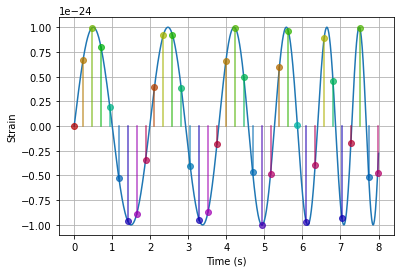

In [6]:
tau = (1+0.003*t_space**3/(0.5*2*pi))*t_space
color_arr = np.multiply(0.7,[colorbar(int(np.mod(i/2, 1)*255)) for i in tau])
pl.plot(t_space, signal)
# pl.plot(t_space, signal, ls='', markevery=mark_idx, marker = 'o')
pl.grid(True)
for i in mark_idx:
    pl.plot([t_space[i]], [signal[i]], marker = 'o', c=color_arr[i])
    pl.plot([t_space[i], t_space[i]], [0, signal[i]], c=color_arr[i])
pl.xlabel("Time (s)")
pl.ylabel("Strain")

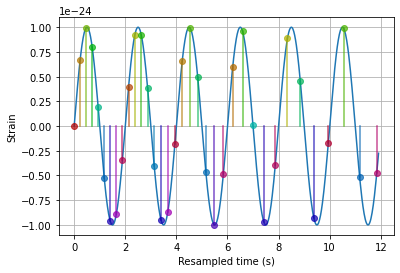

In [7]:
pl.plot(tau, signal)
for i in mark_idx:
    pl.plot([tau[i]], [signal[i]], marker = 'o', c=color_arr[i])
    pl.plot([tau[i], tau[i]], [0, signal[i]], c=color_arr[i])
pl.xlabel("Resampled time (s)")
pl.ylabel("Strain")
pl.grid(True)

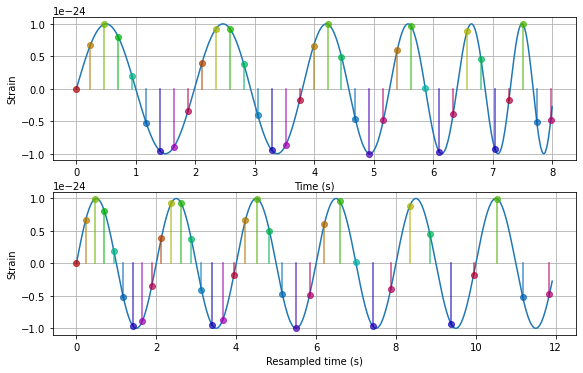

In [8]:
fig, axs = pl.subplots(2, figsize = (8, 5))
fig.tight_layout()

axs[0].plot(t_space, signal)
axs[0].grid(True)
for i in mark_idx:
    axs[0].plot([t_space[i]], [signal[i]], marker = 'o', c=color_arr[i])
    axs[0].plot([t_space[i], t_space[i]], [0, signal[i]], c=color_arr[i])
axs[0].set_xlabel("Time (s)")
axs[0].set_ylabel("Strain")

axs[1].plot(tau, signal)
for i in mark_idx:
    axs[1].plot([tau[i]], [signal[i]], marker = 'o', c=color_arr[i])
    axs[1].plot([tau[i], tau[i]], [0, signal[i]], c=color_arr[i])
axs[1].set_xlabel("Resampled time (s)")
axs[1].set_ylabel("Strain")
axs[1].grid(True)

## Frequency domain

In [9]:
def strobo(beta, data, f_ratio):
    new_t = -3/5*(1-8/3*beta*t)**(5/8)/beta
    f_new = f_signal/f_ratio
    
    new_t *= f_new #changes the frequency to the new downsampled frequency (approximately, not exactly)
    floor_t = np.floor(new_t) #For some reason floor works better than round. Take it to the nearest time index which are integers
    idx = np.nonzero(np.diff(floor_t)) #The step that downsamples
    resampled = data[idx]
    t_out = (new_t[idx]-new_t[0])/f_new
    return (resampled, t_out)

In [10]:
c = 3e8
G = 6.67e-11
pi = np.pi
const = 96/5*pi**(8/3)*(G/c**3)**(5/3)

f0 = 20
Mc = 3e-4* 2e30
f_max = 200
T_obs = 1e3
# pad_len = int(323.4*T_obs) #~0.01 added length to resampled data
beta = const*f0**(8/3)*Mc**(5/3)

f_signal = 40*f_max
nt = round(f_signal*T_obs)
t = np.arange(nt)/f_signal
f_ratio = 25

In [11]:
T_obs = 4e3

f_signal = 24*f_max
nt = round(f_signal*T_obs)
t = np.arange(nt)/f_signal
f_ratio = 8

beta = 4e-6

freq_arr = []
spectrum_arr = []
rs_freq_arr = []
rs_spectrum_arr = []

phi = -6*pi/5*f0*(1-8./3.*beta*t)**(5/8)/beta
phi = np.mod(phi,2*pi)
data = 1*np.exp(1j*phi)

freqs = np.fft.fftshift(np.fft.fftfreq(len(t), d=t[1]-t[0]))
spec = np.fft.fftshift(np.fft.fft(data))
power_spec = np.abs(spec/len(t))**2
freq_arr.append(freqs[len(data)//2 : int(1.1*len(data)//2)])
spectrum_arr.append(power_spec[len(data)//2 : int(1.1*len(data)//2)])

f_ratio = 25
out, t_out = strobo(beta, data, f_ratio)
corrected = np.fft.fftshift(np.fft.fft(out))
freq_corrected = np.fft.fftshift(np.fft.fftfreq(len(t_out), d=t_out[1]-t_out[0]))
freq_corrected = freq_corrected[len(freq_corrected)//2 : int(1.1*len(data)//2)]
corrected = corrected[len(corrected)//2 : int(1.1*len(data)//2)]
resampled_power = np.abs(corrected/len(out))**2

rs_freq_arr.append(freq_corrected)
rs_spectrum_arr.append(resampled_power)

Text(0, 0.5, 'Power')

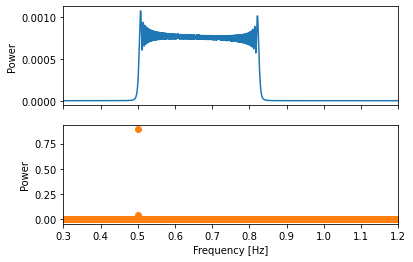

In [12]:
fig, axs = pl.subplots(2, sharex = True)

axs[0].plot(freq_arr[0]-19.5, spectrum_arr[0])
# axs[0].set_xlim(19.9, 20.1)

axs[1].plot(rs_freq_arr[0]-19.5, rs_spectrum_arr[0], 'o', c='tab:orange')
axs[1].set_xlim(0.3, 1.2)

axs[1].set_xlabel("Frequency [Hz]")
axs[1].set_xlabel("Frequency [Hz]")
axs[0].set_ylabel("Power")
axs[1].set_ylabel("Power")

## Combined graphic:

In [13]:
import matplotlib as mpl
mpl.rcParams['figure.dpi'] = 300

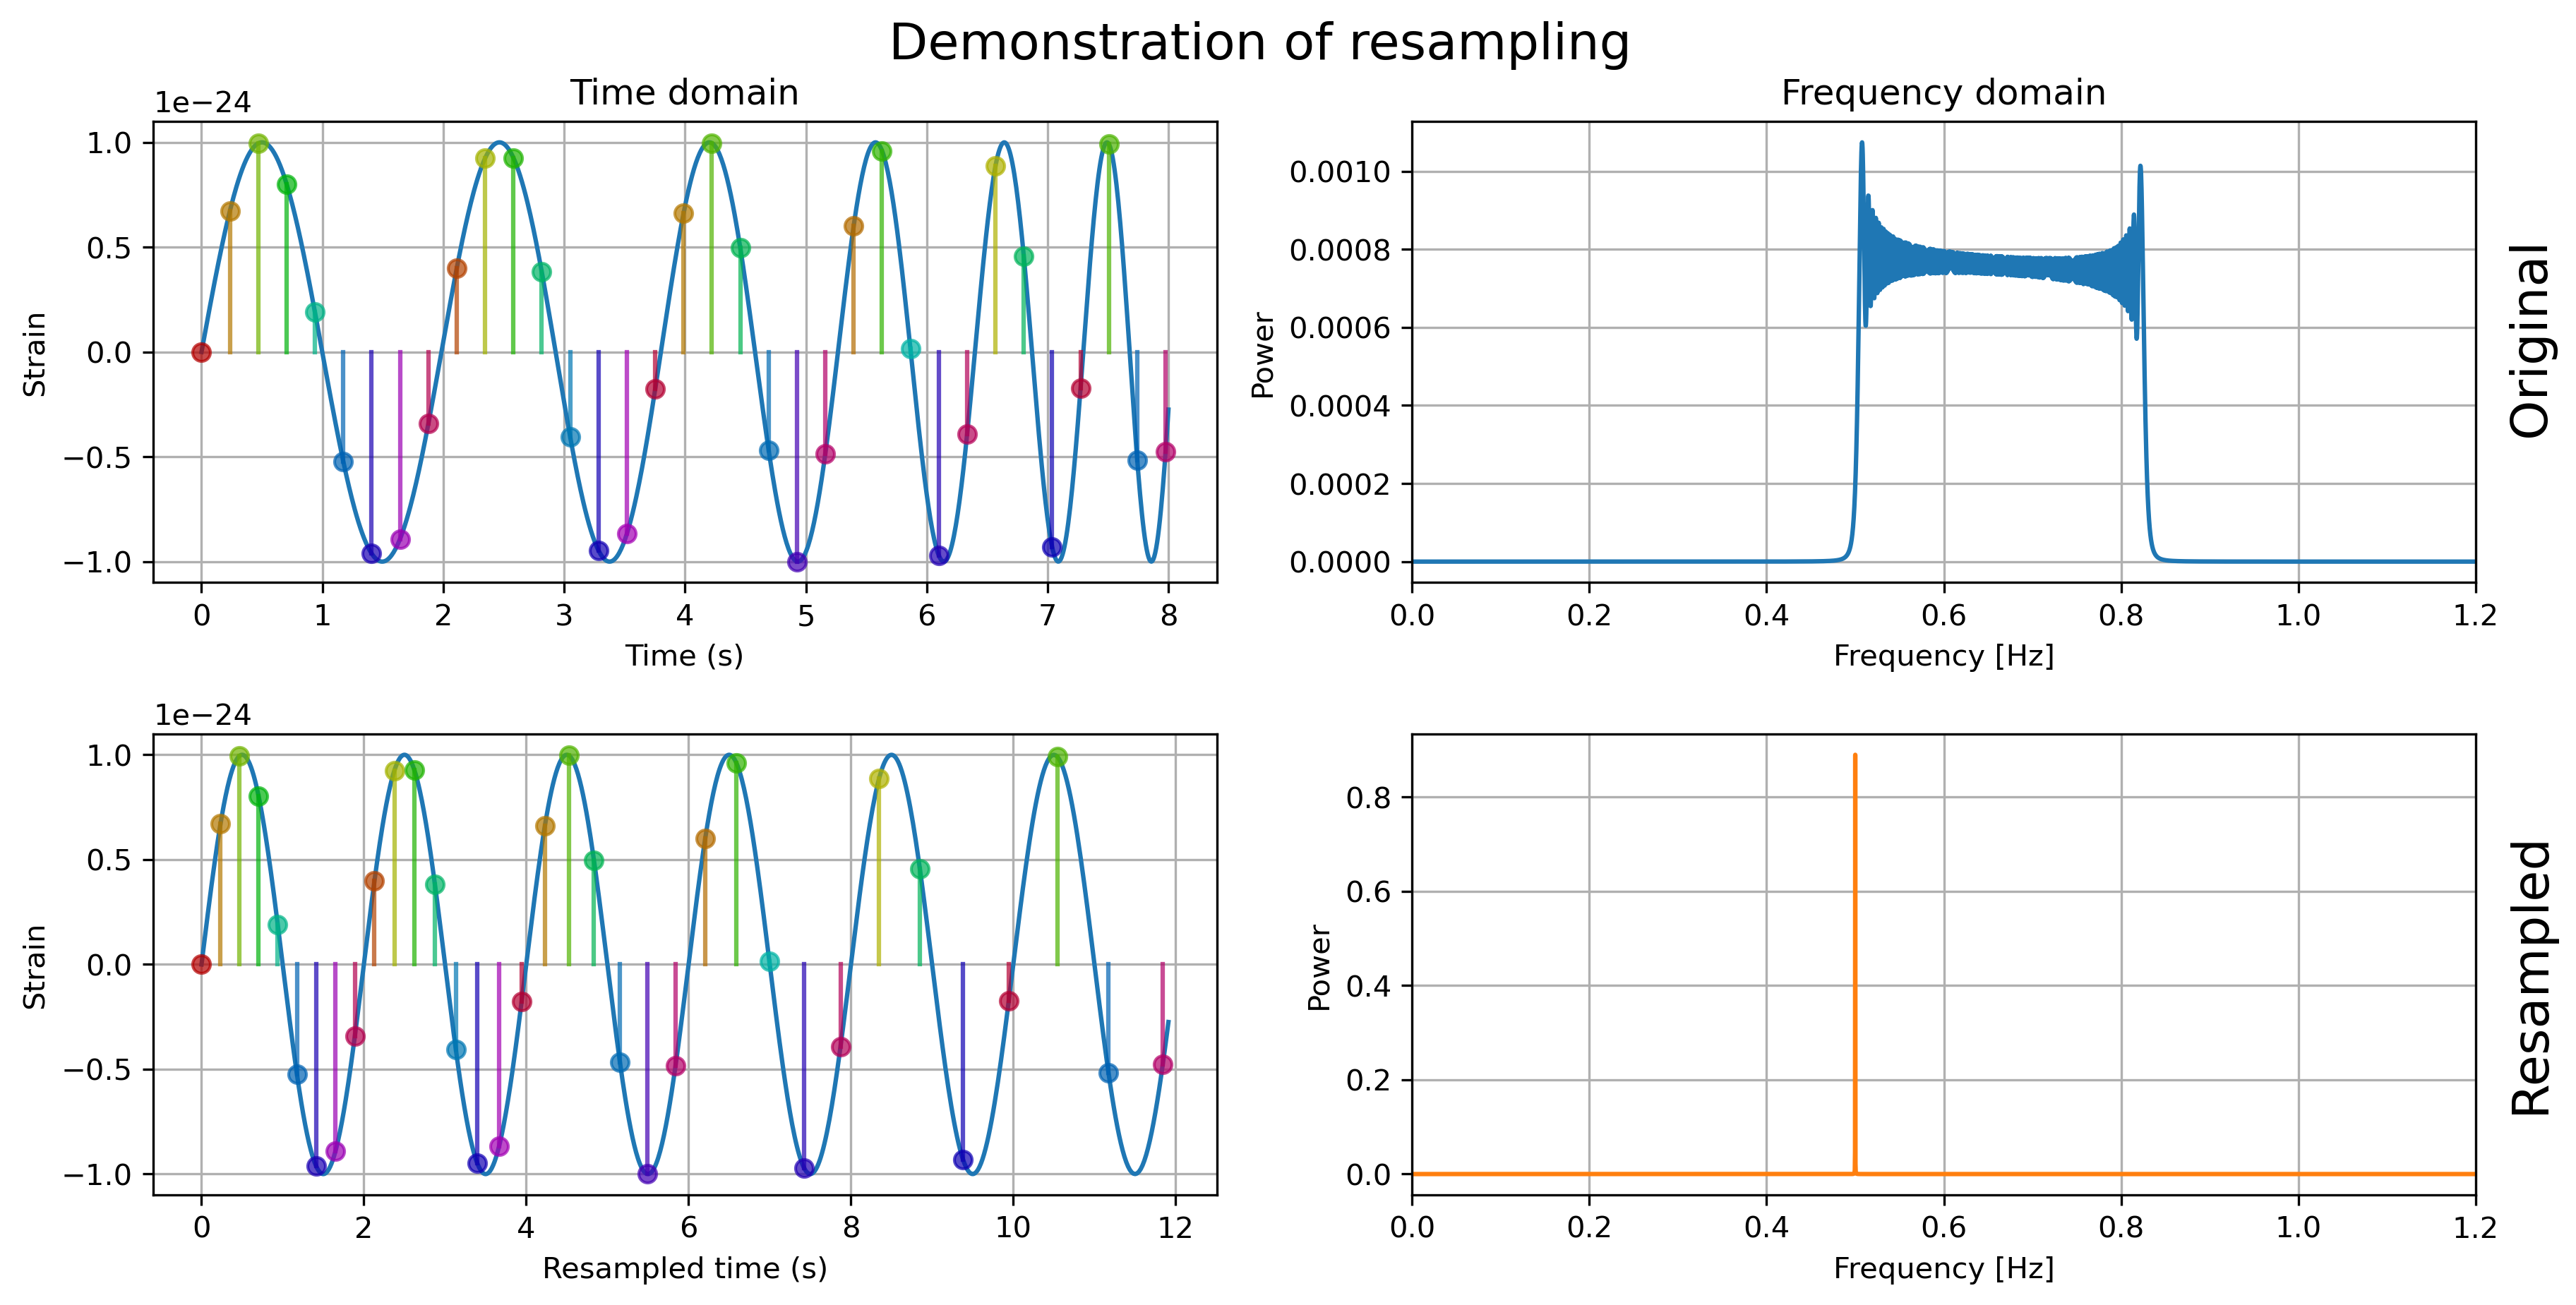

In [15]:
fig, axs = pl.subplots(2,2, figsize = (12, 6))
# subplots_adjust(left=None, bottom=None, right=None, top=None, wspace=None, hspace=None)

axs[0,0].plot(t_space, signal)
axs[0,0].grid(True)
for i in mark_idx:
    axs[0,0].plot([t_space[i]], [signal[i]], marker = 'o', c=color_arr[i])
    axs[0,0].plot([t_space[i], t_space[i]], [0, signal[i]], c=color_arr[i])
axs[0,0].set_xlabel("Time (s)")
axs[0,0].set_ylabel("Strain")

axs[1,0].plot(tau, signal)
for i in mark_idx:
    axs[1,0].plot([tau[i]], [signal[i]], marker = 'o', c=color_arr[i])
    axs[1,0].plot([tau[i], tau[i]], [0, signal[i]], c=color_arr[i])
axs[1,0].set_xlabel("Resampled time (s)")
axs[1,0].set_ylabel("Strain")
axs[1,0].grid(True)

axs[0,1].plot(freq_arr[0]-19.5, spectrum_arr[0])
axs[0,1].set_xlim(0., 1.2)
axs[0,1].grid(True)

axs[1,1].plot(rs_freq_arr[0]-19.5, rs_spectrum_arr[0], c='tab:orange')
axs[1,1].set_xlim(0., 1.2)
axs[1,1].grid(True)
    
axs[0,1].set_xlabel("Frequency [Hz]")
axs[1,1].set_xlabel("Frequency [Hz]")
axs[0,1].set_ylabel("Power")
axs[1,1].set_ylabel("Power")
axs[0,0].set_title("Time domain")
axs[0,1].set_title("Frequency domain")
fig.text(1., 0.77, 'Original', ha='center', va='center', rotation=90, fontsize = 'xx-large')
fig.text(1., 0.27, 'Resampled', ha='center', va='center', rotation=90, fontsize = 'xx-large')
fig.text(0.5, 1.0, 'Demonstration of resampling', ha='center', va='center', fontsize = 'xx-large')
fig.tight_layout()

In [24]:
import finufft

In [30]:
t_space = np.linspace(0, 8, 2**10)
f = 0.5*2*pi + 0.003*t_space**3
signal = 1e-24*np.sin(f*t_space)
tau = t_space/(8)*2*np.pi - np.pi
bin_no = len(t_space)

In [31]:
nufft_amp = finufft.nufft1d1(tau, signal.astype(complex), bin_no)
nufft_freqs = (np.arange(bin_no) - bin_no//2)/(2*pi)

(0.0, 5.0)

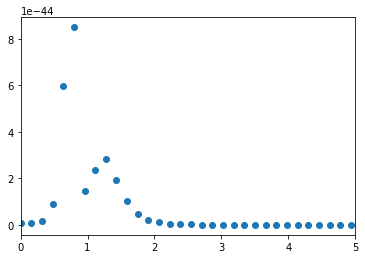

In [33]:
pl.plot(nufft_freqs, abs(nufft_amp)**2, 'o')
pl.xlim(0, 5)